# Graded Response Model — Duckworth Grit Scale (Single Scale)

Fits a single-dimensional GRM to all 12 Grit Scale items.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data

In [2]:
from bayesianquilts.data.grit import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {response_cardinality} response categories (0-{response_cardinality - 1})")
print(f"Item keys: {item_keys}")
df.head()

Dataset: 4270 people, 12 items, 5 response categories (0-4)
Item keys: ['GS1', 'GS2', 'GS3', 'GS4', 'GS5', 'GS6', 'GS7', 'GS8', 'GS9', 'GS10', 'GS11', 'GS12']


person,GS1,GS2,GS3,GS4,GS5,GS6,GS7,GS8,GS9,GS10,GS11,GS12
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,0,0,2,2,2,1,2,0,2,1,2,2
1,1,1,2,2,1,0,2,2,1,0,2,1
2,2,2,2,2,3,2,3,3,2,2,2,2
3,0,2,3,1,3,0,4,3,0,0,2,0
4,0,1,2,2,1,1,1,3,2,2,3,3


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 4270


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 183
N: 4270, Batch size: 256, Steps per epoch: 17


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Final baseline loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:01<?, ?batch/s, best_loss=inf, loss=26.1790]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:01<00:23,  1.49s/batch, best_loss=inf, loss=26.1790]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:01<00:23,  1.49s/batch, best_loss=inf, loss=25.8321]

...

Epoch 29/200 (LR: 0.000104):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=25.0699, loss=25.4482]

Epoch 29/200 (LR: 0.000104):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=25.0699, loss=25.5552]

Epoch 29/200 (LR: 0.000104):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=25.0699, loss=18.7665]

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000101

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
NaN/Inf recovery was triggered 4 times during training.


Final baseline loss: 25.21


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit Pairwise Ordinal Stacking Model

In [8]:
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

# Convert to pandas, replacing -1 (missing marker) with NaN
pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)
print(f"Missing values per item:\n{pandas_df.isna().sum()}")

pairwise_model = PairwiseOrdinalStackingModel(
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

pairwise_model.fit(
    pandas_df,
    n_top_features=12,
    n_jobs=1,
    seed=42,
)

Missing values per item:
GS1     10
GS2     14
GS3     12
GS4     34
GS5     11
GS6     14
GS7     14
GS8     10
GS9      9
GS10    15
GS11    15
GS12    25
dtype: int64
Computing feature correlations...
Fitting PairwiseOrdinalStackingModel
  Variables: 12
  Observations: 4270
  Min obs per model: 5
  Parallel jobs: 1
  Top features per target: 12
  DM alpha prior: 0.5
  Global ordinal values: [0. 1. 2. 3. 4.] (n=5)

Fitting zero-predictor regression models...


  Var 0 (GS1): elpd/n=-0.1579


  Var 1 (GS2): elpd/n=-0.1790


  Var 2 (GS3): elpd/n=-0.1841


  Var 3 (GS4): elpd/n=-0.1846


...


Fitting Dirichlet-multinomial contingency table models...
  Categorical/ordinal variables: 12 of 12
  Zero-predictor DM var 0 (GS1): elpd/n=-1.3228
  Zero-predictor DM var 1 (GS2): elpd/n=-1.4727
  Zero-predictor DM var 2 (GS3): elpd/n=-1.5366
  Zero-predictor DM var 3 (GS4): elpd/n=-1.5233
  Zero-predictor DM var 4 (GS5): elpd/n=-1.5677
  Zero-predictor DM var 5 (GS6): elpd/n=-1.2773
  Zero-predictor DM var 6 (GS7): elpd/n=-1.5412
  Zero-predictor DM var 7 (GS8): elpd/n=-1.5797
  Zero-predictor DM var 8 (GS9): elpd/n=-1.4727
  Zero-predictor DM var 9 (GS10): elpd/n=-1.5520
  Zero-predictor DM var 10 (GS11): elpd/n=-1.4916
  Zero-predictor DM var 11 (GS12): elpd/n=-1.3576
  DM (GS2->GS1): elpd/n=-1.3162, n=4252
  DM (GS3->GS1): elpd/n=-1.3142, n=4254
  DM (GS4->GS1): elpd/n=-1.2573, n=4232
  DM (GS5->GS1): elpd/n=-1.3057, n=4255
  DM (GS6->GS1): elpd/n=-1.2288, n=4252
  DM (GS7->GS1): elpd/n=-1.2974, n=4252
  DM (GS8->GS1): elpd/n=-1.2833, n=4256
  DM (GS9->GS1): elpd/n=-1.2689, n=425

  DM (GS9->GS2): elpd/n=-1.3903, n=4254
  DM (GS10->GS2): elpd/n=-1.4446, n=4248
  DM (GS11->GS2): elpd/n=-1.4219, n=4248
  DM (GS12->GS2): elpd/n=-1.4505, n=4238
  DM (GS1->GS3): elpd/n=-1.5279, n=4254
  DM (GS2->GS3): elpd/n=-1.4590, n=4251
  DM (GS4->GS3): elpd/n=-1.5338, n=4231
  DM (GS5->GS3): elpd/n=-1.4086, n=4254
  DM (GS6->GS3): elpd/n=-1.5180, n=4251
  DM (GS7->GS3): elpd/n=-1.4013, n=4251
  DM (GS8->GS3): elpd/n=-1.4483, n=4255
  DM (GS9->GS3): elpd/n=-1.4947, n=4256
  DM (GS10->GS3): elpd/n=-1.5063, n=4250
  DM (GS11->GS3): elpd/n=-1.4091, n=4250
  DM (GS12->GS3): elpd/n=-1.5148, n=4240
  DM (GS1->GS4): elpd/n=-1.4569, n=4232
  DM (GS2->GS4): elpd/n=-1.5111, n=4229
  DM (GS3->GS4): elpd/n=-1.5201, n=4231
  DM (GS5->GS4): elpd/n=-1.5029, n=4233
  DM (GS6->GS4): elpd/n=-1.4893, n=4230
  DM (GS7->GS4): elpd/n=-1.5022, n=4229
  DM (GS8->GS4): elpd/n=-1.4840, n=4233
  DM (GS9->GS4): elpd/n=-1.4783, n=4234
  DM (GS10->GS4): elpd/n=-1.4867, n=4228
  DM (GS11->GS4): elpd/n=-1.5191,

  DM (GS7->GS5): elpd/n=-1.3820, n=4253
  DM (GS8->GS5): elpd/n=-1.4069, n=4256
  DM (GS9->GS5): elpd/n=-1.4631, n=4257
  DM (GS10->GS5): elpd/n=-1.5087, n=4251
  DM (GS11->GS5): elpd/n=-1.4887, n=4251
  DM (GS12->GS5): elpd/n=-1.5235, n=4241
  DM (GS1->GS6): elpd/n=-1.1834, n=4252
  DM (GS2->GS6): elpd/n=-1.2539, n=4249
  DM (GS3->GS6): elpd/n=-1.2584, n=4251
  DM (GS4->GS6): elpd/n=-1.2440, n=4230
  DM (GS5->GS6): elpd/n=-1.2412, n=4252
  DM (GS7->GS6): elpd/n=-1.2314, n=4250
  DM (GS8->GS6): elpd/n=-1.2060, n=4254
  DM (GS9->GS6): elpd/n=-1.1643, n=4256
  DM (GS10->GS6): elpd/n=-1.1906, n=4249
  DM (GS11->GS6): elpd/n=-1.2703, n=4249
  DM (GS12->GS6): elpd/n=-1.0911, n=4241
  DM (GS1->GS7): elpd/n=-1.5156, n=4252
  DM (GS2->GS7): elpd/n=-1.4297, n=4249
  DM (GS3->GS7): elpd/n=-1.4062, n=4251
  DM (GS4->GS7): elpd/n=-1.5199, n=4229
  DM (GS5->GS7): elpd/n=-1.3555, n=4253
  DM (GS6->GS7): elpd/n=-1.4949, n=4250
  DM (GS8->GS7): elpd/n=-1.3271, n=4254
  DM (GS9->GS7): elpd/n=-1.4262, n

  DM (GS3->GS8): elpd/n=-1.4917, n=4255
  DM (GS4->GS8): elpd/n=-1.5404, n=4233
  DM (GS5->GS8): elpd/n=-1.4189, n=4256
  DM (GS6->GS8): elpd/n=-1.5083, n=4254
  DM (GS7->GS8): elpd/n=-1.3654, n=4254
  DM (GS9->GS8): elpd/n=-1.4212, n=4259
  DM (GS10->GS8): elpd/n=-1.4697, n=4254
  DM (GS11->GS8): elpd/n=-1.5250, n=4254
  DM (GS12->GS8): elpd/n=-1.5098, n=4244
  DM (GS1->GS9): elpd/n=-1.4192, n=4257
  DM (GS2->GS9): elpd/n=-1.3902, n=4254
  DM (GS3->GS9): elpd/n=-1.4309, n=4256
  DM (GS4->GS9): elpd/n=-1.4283, n=4234
  DM (GS5->GS9): elpd/n=-1.3681, n=4257
  DM (GS6->GS9): elpd/n=-1.3600, n=4256
  DM (GS7->GS9): elpd/n=-1.3579, n=4255
  DM (GS8->GS9): elpd/n=-1.3142, n=4259
  DM (GS10->GS9): elpd/n=-1.3530, n=4254
  DM (GS11->GS9): elpd/n=-1.4532, n=4254
  DM (GS12->GS9): elpd/n=-1.3614, n=4245
  DM (GS1->GS10): elpd/n=-1.4510, n=4251
  DM (GS2->GS10): elpd/n=-1.5243, n=4248
  DM (GS3->GS10): elpd/n=-1.5219, n=4250
  DM (GS4->GS10): elpd/n=-1.5153, n=4228
  DM (GS5->GS10): elpd/n=-1.49

  DM (GS1->GS11): elpd/n=-1.4884, n=4252
  DM (GS2->GS11): elpd/n=-1.4407, n=4248
  DM (GS3->GS11): elpd/n=-1.3645, n=4250
  DM (GS4->GS11): elpd/n=-1.4885, n=4228
  DM (GS5->GS11): elpd/n=-1.4130, n=4251
  DM (GS6->GS11): elpd/n=-1.4839, n=4249
  DM (GS7->GS11): elpd/n=-1.3935, n=4249
  DM (GS8->GS11): elpd/n=-1.4371, n=4254
  DM (GS9->GS11): elpd/n=-1.4720, n=4254
  DM (GS10->GS11): elpd/n=-1.4812, n=4250
  DM (GS12->GS11): elpd/n=-1.4858, n=4241
  DM (GS1->GS12): elpd/n=-1.2763, n=4243
  DM (GS2->GS12): elpd/n=-1.3360, n=4238
  DM (GS3->GS12): elpd/n=-1.3364, n=4240
  DM (GS4->GS12): elpd/n=-1.3134, n=4219
  DM (GS5->GS12): elpd/n=-1.3138, n=4241
  DM (GS6->GS12): elpd/n=-1.1717, n=4241
  DM (GS7->GS12): elpd/n=-1.3082, n=4239
  DM (GS8->GS12): elpd/n=-1.2877, n=4244
  DM (GS9->GS12): elpd/n=-1.2463, n=4245
  DM (GS10->GS12): elpd/n=-1.2709, n=4239
  DM (GS11->GS12): elpd/n=-1.3524, n=4241

Completed:
  Regression zero-predictor: 11/12
  Regression univariate: 126/132
  DM zero-pred

In [9]:
pairwise_model.save('pairwise_stacking_model.yaml')
pairwise_model.compute_optimal_stacking_weights()

Optimal stacking weights computed for 12 targets


In [10]:
import pandas as pd

def compare_stacking_weights(model, item_keys):
    """Compare default softmax vs optimal Yao et al. stacking weights."""
    rows = []
    for i, item_key in enumerate(item_keys):
        models_info = []
        if i in model.zero_predictor_results:
            zr = model.zero_predictor_results[i]
            if zr.converged:
                models_info.append(("reg:intercept", zr.elpd_loo_per_obs, zr.elpd_loo_per_obs_se, 0.0))
        for (t, p), r in model.univariate_results.items():
            if t == i and r.converged:
                pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                models_info.append((f"reg:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_zero_results") and i in model.dm_zero_results:
            dmz = model.dm_zero_results[i]
            if dmz.converged:
                models_info.append(("dm:marginal", dmz.elpd_loo_per_obs, dmz.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_results"):
            for (t, p), r in model.dm_results.items():
                if t == i and r.converged:
                    pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                    models_info.append((f"dm:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))

        n_models = len(models_info)
        if n_models == 0:
            rows.append({"Item": item_key, "N": 0, "Eff_def": "-", "Eff_opt": "-",
                         "Top_default": "-", "w_def": "-", "Top_optimal": "-", "w_opt": "-"})
            continue

        elpds = np.array([m[1] for m in models_info])
        ses = np.array([m[2] for m in models_info])
        default_w = model._elpd_weights(elpds, ses, 1.0)

        opt_dict = getattr(model, "_optimal_weights", {}).get(i, {})
        opt_w = np.zeros(n_models)
        for j, (name, _, _, _) in enumerate(models_info):
            parts = name.split(":", 1)
            mtype, mid = parts[0], parts[1] if len(parts) > 1 else ""
            if mid in ("intercept", "marginal"):
                key = (mtype[:3], mid)
            elif mid in model.variable_names:
                key = (mtype[:3], model.variable_names.index(mid))
            else:
                key = (mtype[:3], mid)
            opt_w[j] = opt_dict.get(key, 0.0)
        if opt_w.sum() > 0:
            opt_w /= opt_w.sum()

        def eff_n(w):
            w = w[w > 1e-10]
            return float(np.exp(-np.sum(w * np.log(w)))) if len(w) > 0 else 0

        names = [m[0] for m in models_info]
        top_def = names[np.argmax(default_w)]
        top_opt = names[np.argmax(opt_w)] if opt_w.sum() > 0 else "-"

        rows.append({
            "Item": item_key, "N": n_models,
            "Eff_def": f"{eff_n(default_w):.1f}", "Eff_opt": f"{eff_n(opt_w):.1f}",
            "Top_default": top_def, "w_def": f"{default_w.max():.3f}",
            "Top_optimal": top_opt, "w_opt": f"{opt_w.max():.3f}",
        })
    return pd.DataFrame(rows)

weights_df = compare_stacking_weights(pairwise_model, item_keys)
print("Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)\n")
print(weights_df.to_string(index=False))

Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)

Item  N Eff_def Eff_opt Top_default w_def   Top_optimal w_opt
 GS1 24    20.9    24.0     reg:GS6 0.064 reg:intercept 0.042
 GS2 24    20.4    24.0     reg:GS8 0.066 reg:intercept 0.042
 GS3 24    20.1    24.0     reg:GS5 0.066 reg:intercept 0.042
 GS4 24    20.1    24.0     reg:GS8 0.066 reg:intercept 0.042
 GS5 23    19.2    23.0     reg:GS7 0.071 reg:intercept 0.043
 GS6 23    20.2    23.0    reg:GS12 0.067 reg:intercept 0.043
 GS7 24    20.2    24.0     reg:GS5 0.066 reg:intercept 0.042
 GS8 23    19.2    23.0     reg:GS7 0.071 reg:intercept 0.043
 GS9 22    18.6    22.0     reg:GS8 0.075       reg:GS8 0.045
GS10 23    19.2    23.0     reg:GS1 0.071 reg:intercept 0.043
GS11 23    19.3    23.0     reg:GS3 0.070 reg:intercept 0.043
GS12 24    20.8    24.0     reg:GS6 0.064 reg:intercept 0.042


## 4b. Fit Pairwise-Only GRM

Uses only the pairwise ordinal stacking ensemble (no IRT blending, w=1 for all items).

In [11]:
from bayesianquilts.imputation.mixed import PairwiseOnlyImputationModel

pairwise_imputation = PairwiseOnlyImputationModel(mice_model=pairwise_model)
print(pairwise_imputation.summary())

model_pairwise = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    imputation_model=pairwise_imputation,
    dtype=jnp.float64,
)

print("Warm-starting from baseline model parameters")

res_pairwise = model_pairwise.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    initial_values=model_baseline.params,
)

losses_pairwise = res_pairwise[0]
print(f"Final pairwise loss: {losses_pairwise[-1]:.2f}")
model_pairwise.save_to_disk('grm_pairwise')

Pairwise-Only Imputation (w_mice = 1.0 for all items):
  Variables: 12
  Univariate models: 132


Warm-starting from baseline model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=inf, loss=25.6599]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:00<00:15,  1.05batch/s, best_loss=inf, loss=25.6599]

...

🔧 NaN/Inf detected in loss (loss) at epoch 9, step 136.
   Recovery attempt 10/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000115
   -> Reinitialized optimizer and gradient accumulator
  -> No improvement in loss for 7 check(s).                    
  -> Decaying learning rate to: 0.000112


Epoch 10/200 (LR: 0.000112):   0%|          | 0/17 [00:00<?, ?batch/s]

Epoch 10/200 (LR: 0.000112):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=25.1483, loss=25.9573]

Epoch 10/200 (LR: 0.000112):   0%|          | 0/17 [00:00<?, ?batch/s, best_loss=25.1483, loss=25.5735]

❌ Maximum NaN recovery attempts (10) exceeded. Stopping training.
Final pairwise loss: 25.20


In [12]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=pairwise_model,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

MICE pointwise ELPD computed for 12 items, 4270 people


Item Stacking Weights (Yao et al. 2018, MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt  khat_irt
-----------------------------------------------------
GS1             1.000    -1.2462    -1.5276     0.000
GS2             0.852    -1.3784    -1.5343     0.000
GS3             1.000    -1.4410    -1.7033     0.000
GS4             0.810    -1.4783    -1.5742     0.000
GS5             1.000    -1.4376    -1.5872     0.000
GS6             0.977    -1.1792    -1.4090     0.000
GS7             1.000    -1.3830    -1.6516     0.000
GS8             1.000    -1.4238    -1.7396     0.000
GS9             1.000    -1.3410    -1.5955     0.000
GS10            1.000    -1.4545    -1.6252     0.000
GS11            0.810    -1.4206    -1.5074     0.000
GS12            1.000    -1.2580    -1.5282     0.000


## 5. Fit Mixed GRM (Pairwise + IRT Imputation)

In [13]:
# Check if IRT contributes anything to the mixed model
all_pairwise = all(mixed_imputation.get_item_weight(k) >= 1.0 - 1e-6 for k in item_keys)

if all_pairwise:
    print("All w_IRT ≈ 0 — mixed model is identical to pairwise. Reusing pairwise parameters.")
    model_imputed = model_pairwise
    losses_imputed = losses_pairwise
else:
    print(f"IRT contributes to {sum(1 for k in item_keys if mixed_imputation.get_item_weight(k) < 1.0 - 1e-6)}/{len(item_keys)} items")
    model_imputed = GRModel(
        item_keys=item_keys,
        num_people=SUBSAMPLE_N,
        dim=1,
        response_cardinality=response_cardinality,
        imputation_model=mixed_imputation,
        dtype=jnp.float64,
    )

    # Warm-start from pairwise model's final parameters (not baseline snapshot)
    print("Warm-starting from pairwise model parameters")
    res_imputed = model_imputed.fit(
        data_factory,
        batch_size=BATCH_SIZE,
        dataset_size=SUBSAMPLE_N,
        num_epochs=NUM_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        learning_rate=0.0001,
        lr_decay_factor=0.975,
        patience=10,
        zero_nan_grads=True,
        initial_values=model_pairwise.params,
    )

    losses_imputed = res_imputed[0]
    if losses_imputed:
        print(f"Final mixed loss: {losses_imputed[-1]:.2f}")
    else:
        print("Mixed model training failed — falling back to pairwise")
        model_imputed = model_pairwise
        losses_imputed = losses_pairwise

IRT contributes to 4/12 items
Warm-starting from pairwise model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000100):   0%|          | 0/17 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000100):   6%|▌         | 1/17 [00:00<00:13,  1.17batch/s]

Epoch 1/200 (LR: 0.000100):   6%|▌         | 1/17 [00:00<00:13,  1.17batch/s, best_loss=inf, loss=25.6128]

Epoch 1/200 (LR: 0.000100):   6%|▌         | 1/17 [00:01<00:13,  1.17batch/s, best_loss=inf, loss=25.6850]

...

Epoch 2/200 (LR: 0.000093):  53%|█████▎    | 9/17 [00:00<00:00,  9.58batch/s, best_loss=25.1671, loss=25.3652]

Epoch 2/200 (LR: 0.000093):  53%|█████▎    | 9/17 [00:00<00:00,  9.58batch/s, best_loss=25.1671, loss=18.6845]

  -> No improvement in loss for 1 check(s).                    
  -> Decaying learning rate to: 0.000086


Epoch 3/200 (LR: 0.000086):   0%|          | 0/17 [00:00<?, ?batch/s]

🔧 NaN/Inf detected in loss (loss) at epoch 3, step 30.
   Recovery attempt 3/10
   -> Reduced learning rate to: 0.000084
   -> Reinitialized optimizer and gradient accumulator
🔧 NaN/Inf detected in loss (loss) at epoch 3, step 30.
   Recovery attempt 4/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000082
   -> Reinitialized optimizer and gradient accumulator
🔧 NaN/Inf detected in loss (loss) at epoch 3, step 30.
   Recovery attempt 5/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000080
   -> Reinitialized optimizer and gradient accumulator
🔧 NaN/Inf detected in loss (loss) at epoch 3, step 30.
   Recovery attempt 6/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000078
   -> Reinitialized optimizer and gradient accumulator
🔧 NaN/Inf detected in loss (loss) at epoch 3, step 30.
   Recovery attempt 7/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000076
   -> Reinitialized

In [14]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

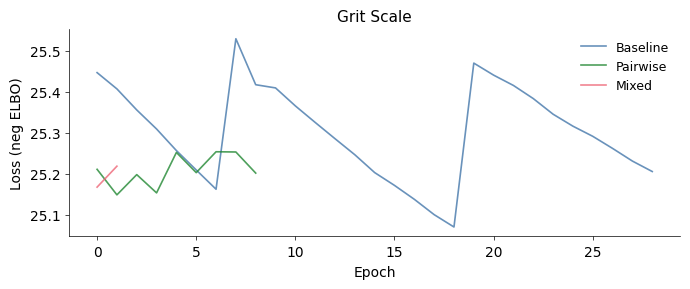

In [15]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='Grit Scale',
                          losses_pairwise=losses_pairwise)
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
calibrate_manually(model_pairwise, n_samples=32, seed=103)
calibrate_manually(model_imputed, n_samples=32, seed=102)

## 7. Ignorability Analysis

Compute per-item adaptive thresholds comparing pairwise imputation ELPD
against baseline IRT ELPD. Items whose missing values are **ignorable**
do not benefit from imputation over the baseline's own marginalization.

In [17]:
model_imputed.compute_adaptive_thresholds(
    data_factory, baseline_model=model_baseline, sample_size=32
)

import pandas as pd
ignorability_df = pd.DataFrame([
    {
        'Item': item,
        'w_pairwise': f"{mixed_imputation.get_item_weight(item):.4f}",
        'Threshold': f"{model_imputed._adaptive_thresholds[item]:.4f}",
        'Missing Ignorable': model_imputed._ignorable_items[item],
    }
    for item in item_keys
])
n_ignorable = sum(model_imputed._ignorable_items[k] for k in item_keys)
print(f"Ignorability: {n_ignorable}/{len(item_keys)} items have ignorable missing values\n")
print(ignorability_df.to_string(index=False))

# Re-save model with thresholds persisted
model_imputed.save_to_disk('grm_imputed')

Ignorability: 0/12 items have ignorable missing values

Item w_pairwise Threshold  Missing Ignorable
 GS1     1.0000    0.0010              False
 GS2     0.8525    0.0010              False
 GS3     1.0000    0.0010              False
 GS4     0.8105    0.0010              False
 GS5     1.0000    0.0010              False
 GS6     0.9770    0.0010              False
 GS7     1.0000    0.0010              False
 GS8     1.0000    0.0010              False
 GS9     1.0000    0.0010              False
GS10     1.0000    0.0010              False
GS11     0.8098    0.0010              False
GS12     1.0000    0.0010              False


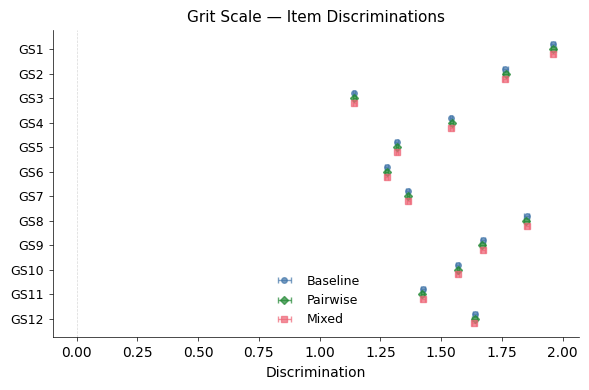

In [18]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed,
                                   title='Grit Scale — Item Discriminations',
                                   model_pairwise=model_pairwise)
fig.savefig('discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

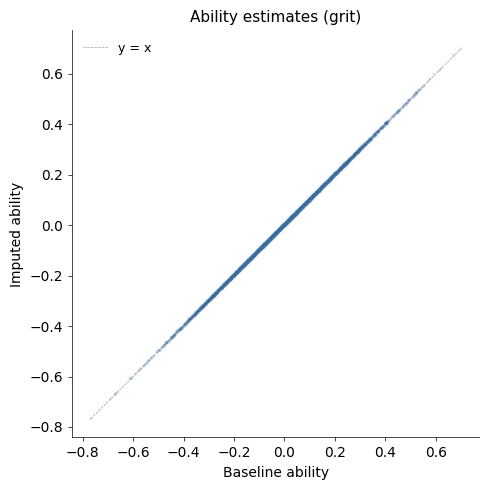

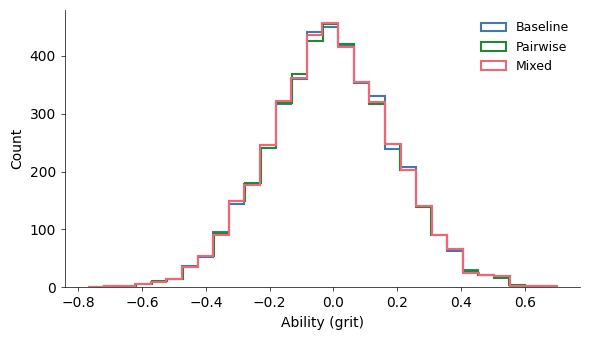

In [19]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_pw = np.array(model_pairwise.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='grit')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='grit',
                                  abilities_pairwise=ab_pw)
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

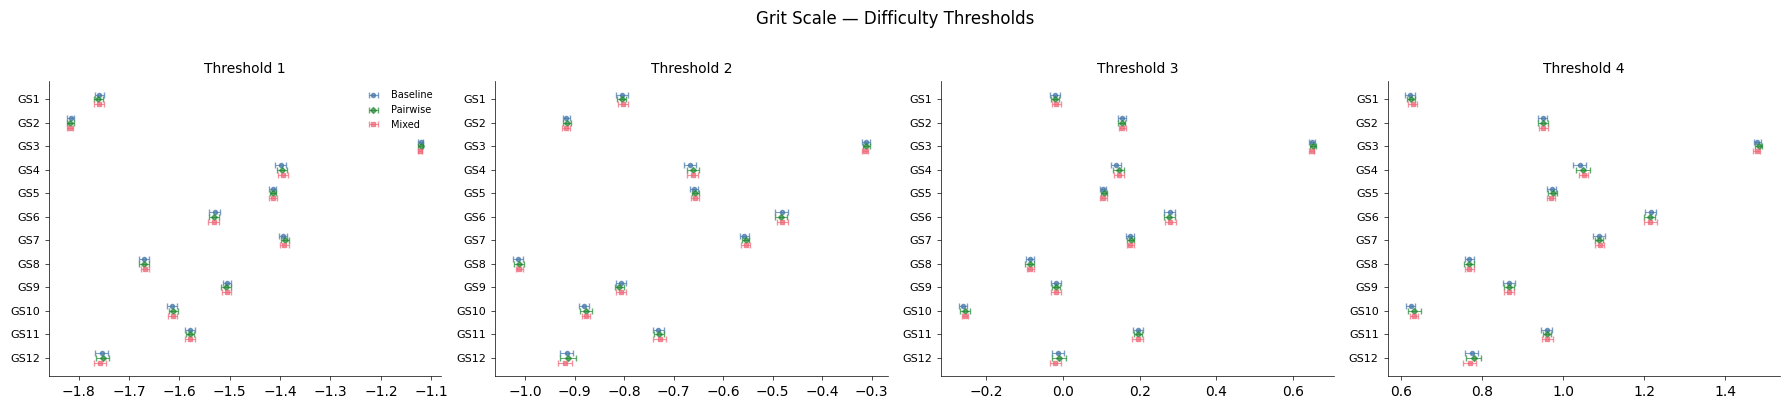

In [20]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed,
                       title='Grit Scale — Difficulty Thresholds',
                       model_pairwise=model_pairwise)
fig.savefig('thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

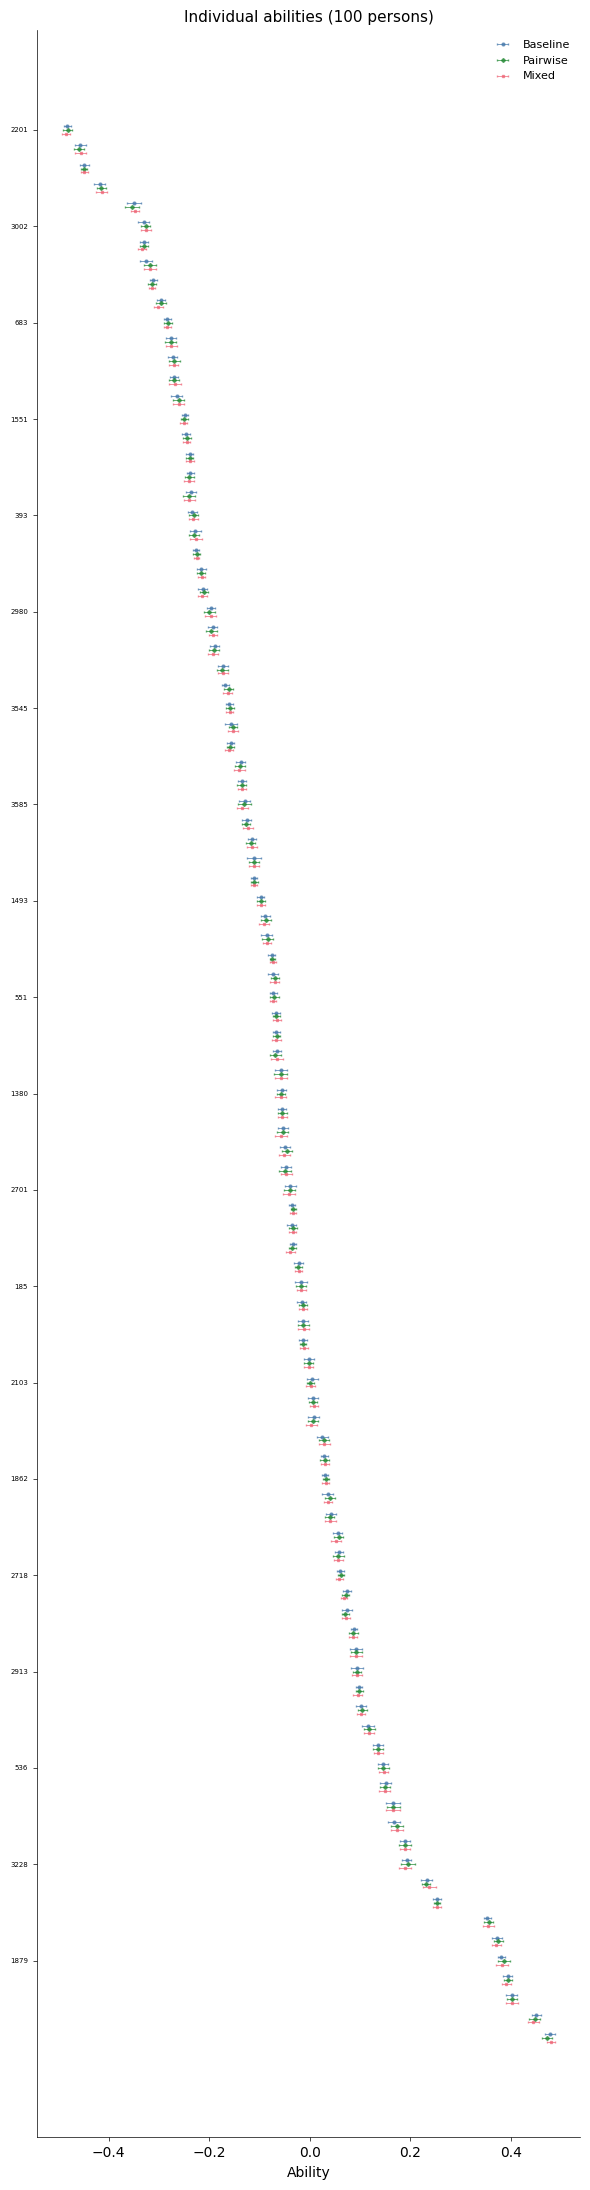

In [21]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed,
                                model_pairwise=model_pairwise)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

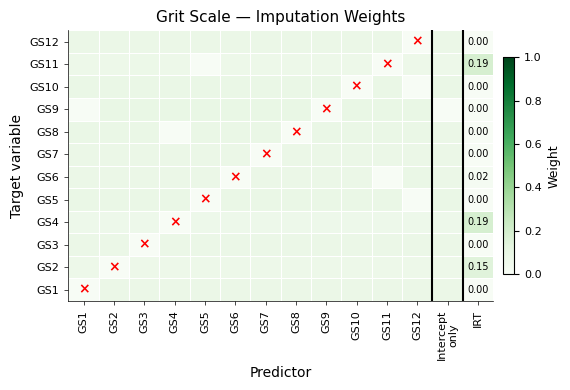

In [22]:
fig = plot_imputation_weights_pcolormesh(pairwise_model, mixed_imputation, item_keys,
                                          title='Grit Scale — Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 8. Model Comparison Table

Predictive performance comparison (RMSE and ELPD) matching the format
of Table 2 in the manuscript.

In [23]:
import pandas as pd

def compute_predictive_metrics(model, data_factory, item_keys, response_cardinality):
    K = response_cardinality
    all_ll, all_se, all_nr = [], [], []
    for batch_data in data_factory():
        pred = model.predictive_distribution(batch_data, **model.surrogate_sample)
        probs = np.array(pred['rv'].probs_parameter())
        S, N_batch, I, _ = probs.shape
        for n in range(N_batch):
            ll, se, nr = 0.0, 0.0, 0
            for i, key in enumerate(item_keys):
                y = batch_data[key][n]
                if np.isnan(y) or y < 0 or y >= K: continue
                y_int = int(y)
                ll += np.log(np.maximum(probs[:, n, i, y_int].mean(), 1e-30))
                se += (np.sum(probs[:, n, i, :].mean(0) * np.arange(K)) - y_int) ** 2
                nr += 1
            if nr > 0: all_ll.append(ll); all_se.append(se); all_nr.append(nr)
    ll, se, nr = np.array(all_ll), np.array(all_se), np.array(all_nr)
    N, total = len(ll), nr.sum()
    return {
        'RMSE': (np.sqrt(se.sum()/total), np.std(np.sqrt(se/nr))/np.sqrt(N)),
        'ELPD/n': (ll.mean(), np.std(ll)/np.sqrt(N)),
        'ELPD/resp': (ll.sum()/total, np.std(ll/nr)/np.sqrt(N)),
    }

metrics_baseline = compute_predictive_metrics(model_baseline, data_factory, item_keys, response_cardinality)
metrics_pairwise = compute_predictive_metrics(model_pairwise, data_factory, item_keys, response_cardinality)
metrics_mixed = compute_predictive_metrics(model_imputed, data_factory, item_keys, response_cardinality)

rows = []
for metric in ['RMSE', 'ELPD/n', 'ELPD/resp']:
    b_val, b_se = metrics_baseline[metric]
    p_val, p_se = metrics_pairwise[metric]
    m_val, m_se = metrics_mixed[metric]
    rows.append({
        'Metric': metric,
        'Baseline': f"{b_val:.3f} ({b_se:.3f})",
        'Pairwise': f"{p_val:.3f} ({p_se:.3f})",
        'Mixed': f"{m_val:.3f} ({m_se:.3f})",
    })

comparison_df = pd.DataFrame(rows)
print("Grit Scale — Predictive Performance Comparison\n")
print(comparison_df.to_string(index=False))

Grit Scale — Predictive Performance Comparison

   Metric        Baseline        Pairwise           Mixed
     RMSE   1.463 (0.005)   1.462 (0.005)   1.462 (0.005)
   ELPD/n -21.347 (0.045) -21.341 (0.045) -21.342 (0.045)
ELPD/resp  -1.783 (0.004)  -1.782 (0.004)  -1.782 (0.004)


## Summary

This notebook fitted a single-scale Graded Response Model to
all 12 Duckworth Grit Scale items (GS1--GS12) with 5 response categories (0--4).

Three models were compared:

1. **Baseline GRM** -- treats missing responses as ignorable.
2. **Pairwise GRM** -- uses only the pairwise ordinal stacking ensemble
   (ordinal regression + Dirichlet-multinomial models, w=1 for all items).
3. **Mixed GRM** -- blends the pairwise ensemble with the baseline IRT model's
   marginalized predictions via per-item stacking weights.

The ignorability analysis determines which items' missing values can be
safely treated as ignorable (where the pairwise model does not improve
over the IRT model's own marginalization).